In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_regression, make_classification



In [3]:
x, y = make_regression(n_samples=10, n_features=1)
x, y

(array([[-0.42131006],
        [-0.25124668],
        [ 0.37034451],
        [-0.24473266],
        [-1.99466439],
        [-2.04917353],
        [ 0.34609409],
        [ 1.3099041 ],
        [-2.01330753],
        [ 0.96361796]]),
 array([-0.37092179, -0.22119782,  0.32605167, -0.21546288, -1.75610448,
        -1.80409438,  0.30470158,  1.15324085, -1.77251792,  0.8483702 ]))

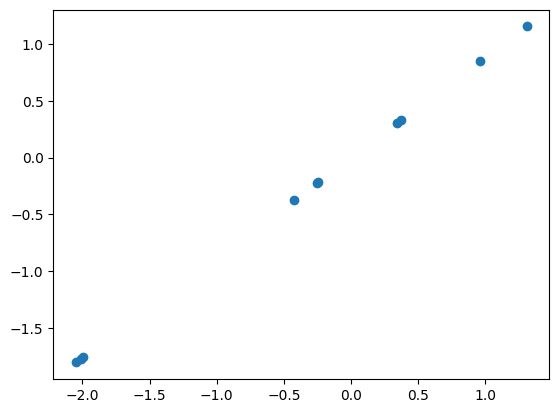

In [5]:
plt.scatter(x, y);

In [7]:
x, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
x.shape, y.shape

((200, 1), (200,))

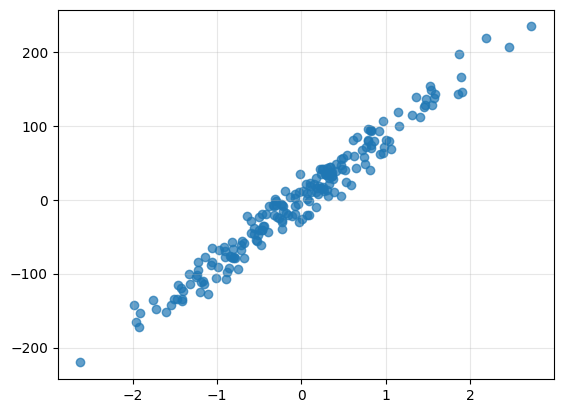

In [10]:
plt.scatter(x, y, alpha=0.7);
plt.grid(True, alpha=0.3);

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((160, 1), (40, 1), (160,), (40,))

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()


In [15]:
x_train_scaled = x_scaler.fit_transform(x_train)
x_test_scaled = x_scaler.transform(x_test)

In [16]:
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

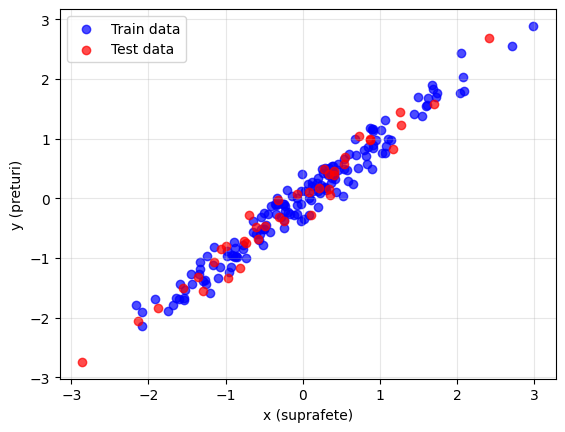

In [27]:
plt.scatter(x_train_scaled, y_train_scaled, alpha=0.7, c="blue", label="Train data");
plt.scatter(x_test_scaled, y_test_scaled,  alpha=0.7, c="red", label="Test data");
plt.grid(True, alpha=0.3);
plt.xlabel("x (suprafete)");
plt.ylabel("y (preturi)");
plt.legend();

In [33]:
model_lin = tf.keras.Sequential([
    ## INPUT
    tf.keras.layers.Input(shape=(1,)),

    ## OUTPUT
    tf.keras.layers.Dense(1),
])

model_lin.compile(optimizer="adam", loss="mse", metrics=["mae"])

model_lin.summary()




Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
model_history = model_lin.fit(x_train, y_train, epochs=10)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 6482.4600 - mae: 63.7353
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6481.7471 - mae: 63.7317
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6481.0283 - mae: 63.7282
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6480.3320 - mae: 63.7248
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6479.6011 - mae: 63.7213
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6478.8867 - mae: 63.7178
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6478.2446 - mae: 63.7144
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6477.5029 - mae: 63.7109
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6476.8252 - mae: 63.7075
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6476.1191 - mae: 63.7039
